In [3]:
from diffusers import BitsAndBytesConfig, SD3Transformer2DModel
from diffusers import StableDiffusion3Pipeline
import torch
from diffusers import StableDiffusion3Pipeline, DiffusionPipeline, StableDiffusionPipeline, \
    DPMSolverMultistepScheduler, AutoPipelineForText2Image

In [105]:
class SDXLpipe:
    def __init__(self):
        self.base = DiffusionPipeline.from_pretrained(
            "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
        )
        self.base.to("cuda")
        self.refiner = DiffusionPipeline.from_pretrained(
            "stabilityai/stable-diffusion-xl-refiner-1.0",
            text_encoder_2=self.base.text_encoder_2,
            vae=self.base.vae,
            torch_dtype=torch.float16,
            use_safetensors=True,
            variant="fp16",
        )
        self.refiner.to("cuda")
        self.base.enable_model_cpu_offload()
        self.refiner.enable_model_cpu_offload()
        
    def __call__(self,prompt,n_steps= 40, high_noise_frac = 0.8):
        
        # run both experts
        image = self.base(
            prompt=prompt,
            num_inference_steps=n_steps,
            denoising_end=high_noise_frac,
            output_type="latent",
        ).images
        print("Done base")
        image = self.refiner(
            prompt=prompt,
            num_inference_steps=n_steps,
            denoising_start=high_noise_frac,
            image=image,
        )
        return image

In [ ]:


pipe21 = StableDiffusionPipeline.from_pretrained("stabilityai/stable-diffusion-2-1", torch_dtype=torch.float16)
pipe21.scheduler = DPMSolverMultistepScheduler.from_config(pipe21.scheduler.config)
pipe21 = pipe21.to("cuda")
pipe21.enable_model_cpu_offload()

pipe21tb = AutoPipelineForText2Image.from_pretrained("stabilityai/sd-turbo", torch_dtype=torch.float16, variant="fp16")
pipe21tb = pipe21tb.to("cuda")
pipe21tb.enable_model_cpu_offload()

pipeXL = SDXLpipe()

pipeXLtb = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipeXLtb = pipeXLtb.to("cuda")
pipeXLtb.enable_model_cpu_offload()

pipe35med = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-medium", torch_dtype=torch.bfloat16)
pipe35med = pipe35med.to("cuda")
pipe35med.enable_model_cpu_offload()

pipe35ltb = StableDiffusion3Pipeline.from_pretrained("stabilityai/stable-diffusion-3.5-medium", torch_dtype=torch.bfloat16)
pipe35ltb = pipe35ltb.to("cuda")
pipe35ltb.enable_model_cpu_offload()

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 1.7 s, sys: 158 ms, total: 1.86 s
Wall time: 562 ms


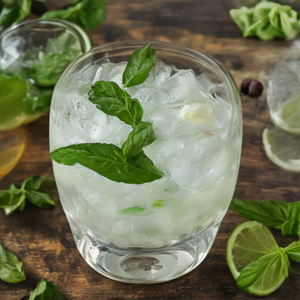

In [112]:
%%time
image = pipe21tb(
    "a dish or a drink named Gin Basil Smash.",
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]
image.resize((300,300))

  0%|          | 0/30 [00:00<?, ?it/s]

CPU times: user 3.26 s, sys: 902 ms, total: 4.16 s
Wall time: 2.87 s


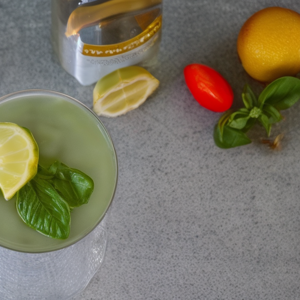

In [109]:
%%time
image = pipe21(
    "a dish or a drink named Gin Basil Smash.",
    num_inference_steps=30,
    guidance_scale=3.5,
).images[0]
image.resize((300,300))

  0%|          | 0/23 [00:00<?, ?it/s]

Done base


  0%|          | 0/7 [00:00<?, ?it/s]

CPU times: user 9.11 s, sys: 1.8 s, total: 10.9 s
Wall time: 7.09 s


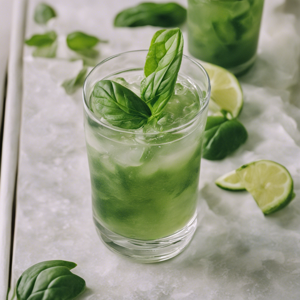

In [113]:
%%time
image = pipeXL(
    "a dish or a drink named Gin Basil Smash.",
    n_steps=30
).images[0]
image.resize((300,300))

  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 4.98 s, sys: 358 ms, total: 5.33 s
Wall time: 1.4 s


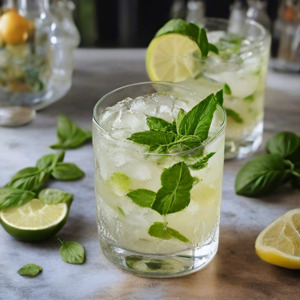

In [44]:
%%time
image = pipeXLtb(
    "a dish or a drink named Gin Basil Smash.",
    num_inference_steps=1,
    guidance_scale=0.0,
).images[0]
image.resize((300,300))

  0%|          | 0/40 [00:00<?, ?it/s]

CPU times: user 10.1 s, sys: 10.2 s, total: 20.3 s
Wall time: 18.9 s


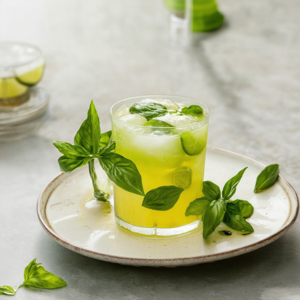

In [114]:
%%time
image = pipe35med(
    "a dish or a drink named Gin Basil Smash.",
    num_inference_steps=40,
    guidance_scale=4.5,
).images[0]
image.resize((300,300))

  0%|          | 0/20 [00:00<?, ?it/s]

CPU times: user 5.12 s, sys: 4.75 s, total: 9.87 s
Wall time: 8.55 s


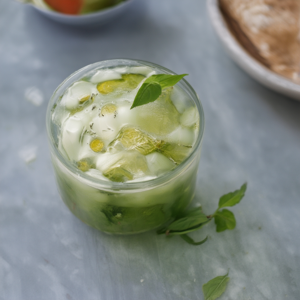

In [117]:
%%time
image = pipe35ltb(
    "a dish or a drink named Gin Basil Smash.",
    num_inference_steps=20,
    guidance_scale=0.0,
).images[0]
image.resize((300,300))

In [37]:
from diffusers import BitsAndBytesConfig, SD3Transformer2DModel
from diffusers import StableDiffusion3Pipeline
from transformers import T5EncoderModel
import sentencepiece
import torch

model_id = "stabilityai/stable-diffusion-3.5-large-turbo"

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)
model_nf4 = SD3Transformer2DModel.from_pretrained(
    model_id,
    subfolder="transformer",
    quantization_config=nf4_config,
    torch_dtype=torch.bfloat16
)

t5_nf4 = T5EncoderModel.from_pretrained("diffusers/t5-nf4", torch_dtype=torch.bfloat16)

pipeline = StableDiffusion3Pipeline.from_pretrained(
    model_id, 
    transformer=model_nf4,
    text_encoder_3=t5_nf4,
    torch_dtype=torch.bfloat16
)
pipeline.enable_model_cpu_offload()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

CPU times: user 6.54 s, sys: 4.15 s, total: 10.7 s
Wall time: 9.44 s


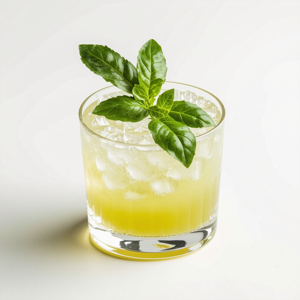

In [58]:
%%time
prompt = "a dish or a drink named Gin Basil Smash."

image = pipeline(
    prompt=prompt,
    num_inference_steps=20,
    guidance_scale=0,
    max_sequence_length=512
).images[0]
image.resize((300,300))

In [77]:
1314/60

21.9

In [80]:
%%time
# discarded titles: 438
# diffusion prompts: 1314
import json
from pathlib import Path
with open("DiffusionPrompts.json", "r") as f:
    loaded_list = json.load(f)

new_split = []
base_dir = "./additional_images/"
Path(base_dir).mkdir(parents=True, exist_ok=True)
i = 0 
for pair in loaded_list:
    title = pair[0]
    prompt = pair[1]
    print(title, prompt)
    # image = pipeline(
    #     prompt=prompt,
    #     num_inference_steps=20,
    #     guidance_scale=0,
    #     max_sequence_length=512
    # ).images[0]
    image = pipeXLtb(
        prompt=prompt,
        num_inference_steps=1,
        guidance_scale=0.0,
    ).images[0]

    image.save(f"{base_dir}{i}_{title}.jpg")
    new_split.append([title, f"{title}.jpg"])
    i+=1

with open(f"{base_dir}NewTrainSplit.json", "w") as f:
    json.dump(new_split, f, indent=4) 

Tuna, Fresh Mozzarella, and Basil Pizza A dish or a drink named Tuna, Fresh Mozzarella, and Basil Pizza.


  0%|          | 0/1 [00:00<?, ?it/s]

Tuna, Fresh Mozzarella, and Basil Pizza A dish or a drink named Tuna, Fresh Mozzarella, and Basil Pizza, surounded by different food.


  0%|          | 0/1 [00:00<?, ?it/s]

Tuna, Fresh Mozzarella, and Basil Pizza A dish or a drink named Tuna, Fresh Mozzarella, and Basil Pizza, seen from really close.


...

Black Bean and Zucchini Chilaquiles A dish or a drink named Black Bean and Zucchini Chilaquiles, surounded by different food.


  0%|          | 0/1 [00:00<?, ?it/s]

Black Bean and Zucchini Chilaquiles A dish or a drink named Black Bean and Zucchini Chilaquiles, surounded by the same food.


  0%|          | 0/1 [00:00<?, ?it/s]

CPU times: user 1h 40min 33s, sys: 7min 16s, total: 1h 47min 49s
Wall time: 29min 56s
